# Lab: Polynomial Regression

*In this lab, we will build a **Polynomial Regression** model using scikit-learn, guided by the [Foundational Methodology for Data Science](../../../05_methodology/). While real-world projects require comprehensive documentation at each stage, this lab focuses on a streamlined, practical approach to demonstrate the core concepts and workflow. Therefore we will settle with the summaries of hypothetical stage reports.*

---

## Stages 1-5
This lab notebook builds directly on the findings from the [Multiple Linear Regression Lab](./07_multiple_linear_regression_lab.ipynb), where we aimed to build a predictive model using data on TV, Radio, and Newspaper advertising to better explain sales variance and guide budget allocation. Therefore Stages 1 through 5 (Business Understanding, Analytic Approach, Data Requirements, Data Collection, and Data Understanding) are considered complete. We will proceed directly with preparing the data for our new Polynomial Regression model.

---

> ### 📝 1-5. Previous Stages Report (Summary)
> *   **Strong Initial Performance:** The Multiple Linear Regression model achieved a high R-squared of **~0.90**, explaining about 90% of the variance in sales.
> *   **Key Insight:** The model identified `TV` and `Radio` as strong, statistically significant predictors, while proving that `Newspaper` spend was statistically insignificant.
> *   **Critical Flaw:** The model's **residual plot showed a distinct U-shaped pattern**, indicating that it systematically under-predicted sales for low and high-spending markets and over-predicted for mid-range markets. This violated the linearity assumption.
> *   **Decision and Next Steps:** Due to the systematic errors revealed in the residual analysis, the decision was **"No-Go for Deployment."** The recommended next step was to use that model as a baseline model and to experiment with a new candidate model capable of capturing non-linear relationships.
>


---

## Stage 6: Data Preparation
Again, we won't need a data cleaning step, but we still need to import necessary libraries and load our data.

In [22]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (8, 6)

In [23]:
sales_df = pd.read_csv("./data/advertising.csv", usecols=['TV', 'Radio', 'Newspaper', 'Sales'])
sales_df.columns = [col.lower() for col in sales_df.columns]
sales_df.head()

,tv,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### 6.1. Final Dataset Split
This time we will define two feature matrices: one with all three features (`TV`, `Radio`, and `Newspaper`) and another with only the two significant features (`TV` and `Radio`). We will then split both datasets into training and testing sets.

In [24]:
# Create feature matrices and target vector
X_all = sales_df[['tv', 'radio', 'newspaper']]
X_significant = sales_df[['tv', 'radio']]
y = sales_df['sales']

# Split the data into training and testing sets
X_all_train, X_all_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)
X_sig_train, X_sig_test, _, _ = train_test_split(X_significant, y, test_size=0.2, random_state=42)

# Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)

# Transform the feature matrices
X_all_train_poly = poly.fit_transform(X_all_train)
X_all_test_poly = poly.transform(X_all_test)

X_sig_train_poly = poly.fit_transform(X_sig_train)
X_sig_test_poly = poly.transform(X_sig_test)

---

> ### 📝 6. Data Preparation Report (Summary)
> *   **Data Loading:** The advertising dataset was successfully loaded, containing columns for `TV`, `Radio`, `Newspaper`, and `Sales`.
> *   **Feature Selection:** Two feature matrices were created: one with all three advertising channels and another with only `TV` and `Radio`, based on prior significance analysis.
> *   **Data Splitting:** Both datasets were split into training (80%) and testing (20%) sets using a fixed random state for reproducibility.

---

## 7. Modeling


### 7.1. Load the Baseline Model
Our base model is the Multiple Linear Regression model from the previous lab. Let's load it first.

In [25]:
mlr_model = joblib.load("./models/multiple_linear_regression_model.pkl")

### 7.2. Train Candidate Models
Now we will create two Polynomial Regression models: one using all three features and another using only the two significant features.

In [26]:
poly_all_model = LinearRegression().fit(X_all_train_poly, y_train)
poly_sig_model = LinearRegression().fit(X_sig_train_poly, y_train)

> ### 📝 7. Modeling Report (Summary)
> *   **Baseline Model:** The Multiple Linear Regression model was loaded as a baseline for comparison.
> *   **Candidate Models:** Two Polynomial Regression models were trained: one with all three features and another with only `TV` and `Radio`.
> *   **Model Training:** Both models were trained on their respective training sets using polynomial features of degree 2.

---

## Stage 8: Evaluation

### 8.1. Evaluation Metrics
Now we will evaluate the performance of all three models on the test set using R-squared and RMSE metrics.

In [27]:
# Multiple Linear Regression Model Predictions and Evaluation Metrics
y_pred_mlr = mlr_model.predict(X_all_test)
mse_mlr = mean_squared_error(y_test, y_pred_mlr)
r2_mlr = r2_score(y_test, y_pred_mlr)

# Polynomial Regression Model (All Features) Predictions and Evaluation Metrics
y_pred_poly_all = poly_all_model.predict(X_all_test_poly)
mse_poly_all = mean_squared_error(y_test, y_pred_poly_all)
r2_poly_all = r2_score(y_test, y_pred_poly_all)

# Polynomial Regression Model (Significant Features) Predictions and Evaluation Metrics
y_pred_poly_sig = poly_sig_model.predict(X_sig_test_poly)
mse_poly_sig = mean_squared_error(y_test, y_pred_poly_sig)
r2_poly_sig = r2_score(y_test, y_pred_poly_sig)

# Print evaluation metrics
print("Multiple Linear Regression Model:")
print(f"  MSE: {mse_mlr:.4f}")
print(f"  R²: {r2_mlr:.4f}")
print("Polynomial Regression Model (All Features):")
print(f"  MSE: {mse_poly_all:.4f}")
print(f"  R²: {r2_poly_all:.4f}")
print("Polynomial Regression Model (Significant Features):")
print(f"  MSE: {mse_poly_sig:.4f}")
print(f"  R²: {r2_poly_sig:.4f}")

Multiple Linear Regression Model:
  MSE: 3.1741
  R²: 0.8994
Polynomial Regression Model (All Features):
  MSE: 0.4129
  R²: 0.9869
Polynomial Regression Model (Significant Features):
  MSE: 0.3642
  R²: 0.9885


* 📌 The Polynomial Regression model using only the significant features (`TV` and `Radio`) outperformed both the baseline Multiple Linear Regression model and the Polynomial Regression model using all features.
* 📌 This model achieved the highest R-squared (0.9885) and the lowest RMSE (0.3642), indicating it best captures the underlying relationship in the data without overfitting.

### 8.2. Evaluation Plots
We will now evaluate the models by using some plots. Let's start with comparing the actual values to the predicted ones.

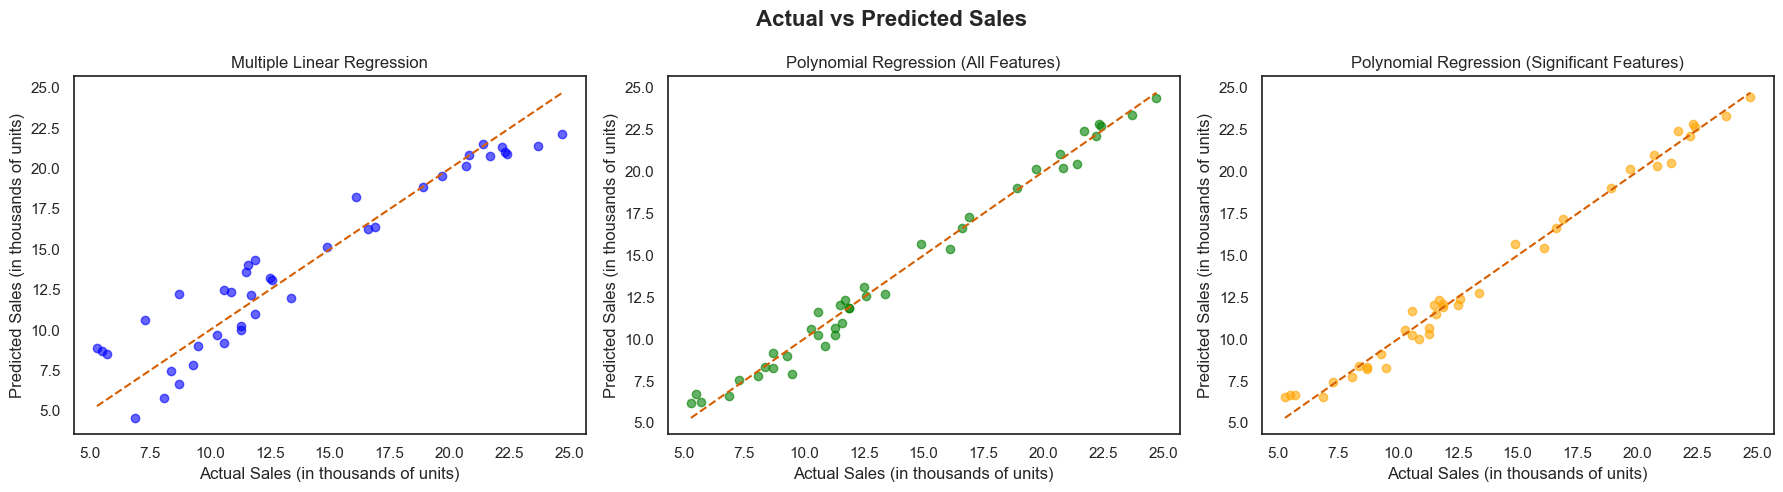

In [28]:
# Actual vs predicted sales for each model
plt.figure(figsize=(18, 5))
plt.suptitle('Actual vs Predicted Sales', fontsize=16, fontweight='bold')

plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_mlr, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Multiple Linear Regression')
plt.xlabel('Actual Sales (in thousands of units)')
plt.ylabel('Predicted Sales (in thousands of units)')

plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_poly_all, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Polynomial Regression (All Features)')
plt.xlabel('Actual Sales (in thousands of units)')
plt.ylabel('Predicted Sales (in thousands of units)')

plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred_poly_sig, color='orange', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Polynomial Regression (Significant Features)')
plt.xlabel('Actual Sales (in thousands of units)')
plt.ylabel('Predicted Sales (in thousands of units)')

plt.tight_layout()
plt.show()

* 📌 The plot above clearly indicates that the Polynomial Regression model with degree 2 and using only `TV` and `Radio` as predictors provides the best fit to the data, closely aligning with the ideal diagonal line. This suggests that this model accurately captures the relationship between the predictors and sales, outperforming both the Multiple Linear Regression model and the Polynomial Regression model using all features.

Now let's see whether the residuals show any patterns.

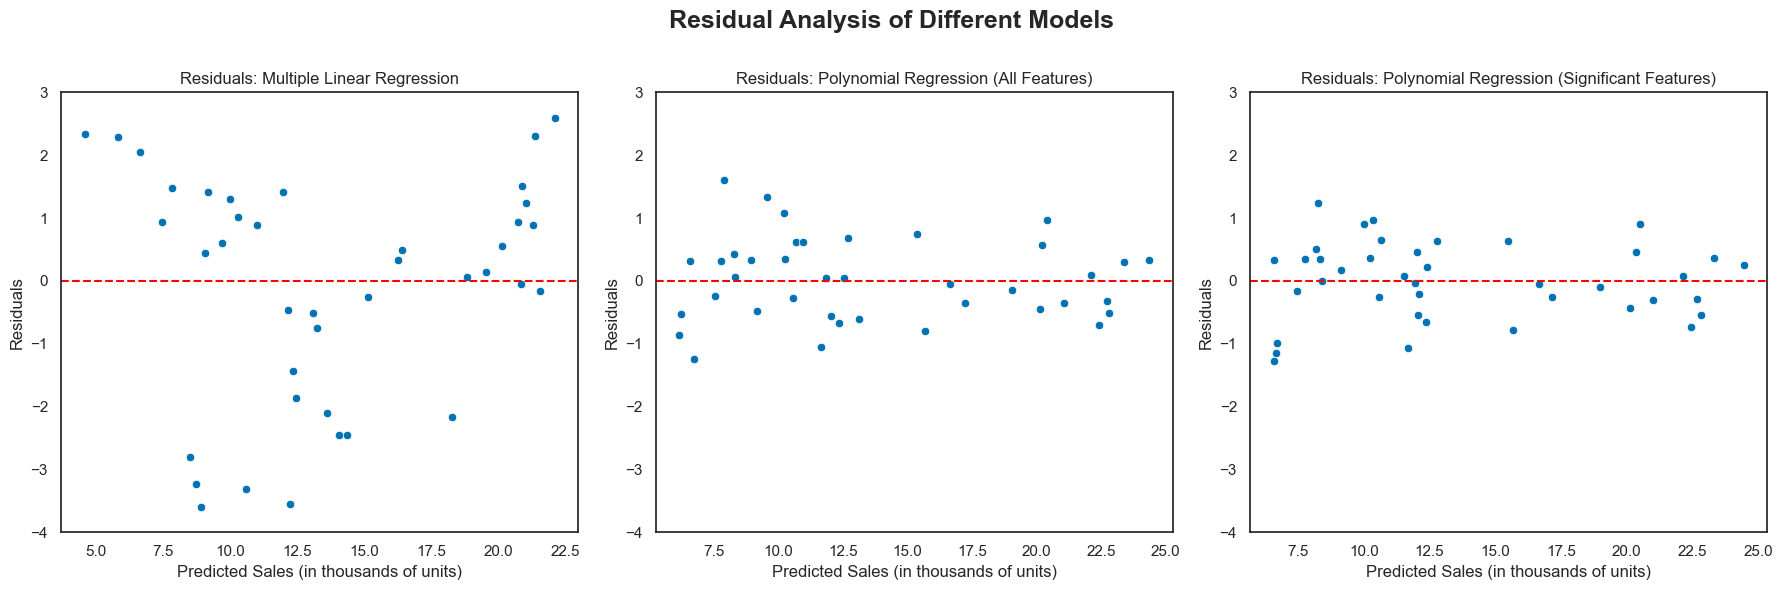

In [36]:
# Residual Analysis
residuals_mlr = y_test - y_pred_mlr
residuals_poly_all = y_test - y_pred_poly_all
residuals_poly_sig = y_test - y_pred_poly_sig

plt.figure(figsize=(18, 6))
plt.suptitle('Residual Analysis of Different Models', fontsize=18, fontweight='bold')

# First row: Residuals vs Predicted Sales
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_pred_mlr, y=residuals_mlr)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals: Multiple Linear Regression')
plt.xlabel('Predicted Sales (in thousands of units)')
plt.ylabel('Residuals')
plt.ylim(-4, 3)

plt.subplot(1, 3, 2)
sns.scatterplot(x=y_pred_poly_all, y=residuals_poly_all)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals: Polynomial Regression (All Features)')
plt.xlabel('Predicted Sales (in thousands of units)')
plt.ylabel('Residuals')
plt.ylim(-4, 3)

plt.subplot(1, 3, 3)
sns.scatterplot(x=y_pred_poly_sig, y=residuals_poly_sig)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals: Polynomial Regression (Significant Features)')
plt.xlabel('Predicted Sales (in thousands of units)')
plt.ylabel('Residuals')
plt.ylim(-4, 3)

plt.tight_layout(rect=(0, 0, 1, 0.975))
plt.show()

* 📌 The residual plot for the Polynomial Regression model with degree 2 and using only `TV` and `Radio` as predictory, which performed better than the other two candidates, also shows a random scatter around zero, indicating that the model has effectively captured the non-linear relationship in the data.  
* 📌 The Q-Q plot for the same model shows that the residuals are approximately normally distributed, with most points falling along the diagonal line. This further validates the model's assumptions and its effectiveness in capturing the underlying data patterns.

, and whether they are normally distributed.


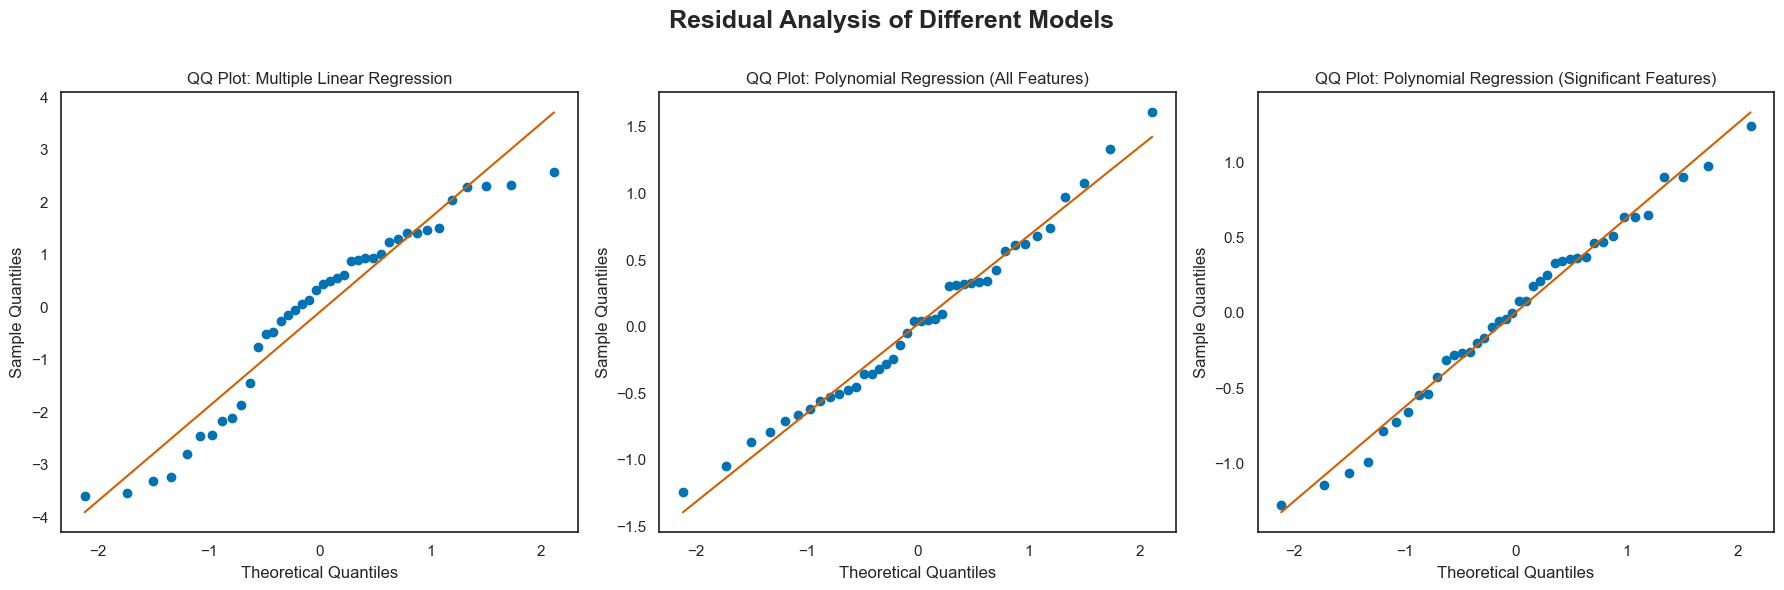

In [40]:
# Q-Q Plots
plt.figure(figsize=(18, 6))
plt.suptitle('Residual Analysis of Different Models', fontsize=18, fontweight='bold')

plt.subplot(1, 3, 1)
stats.probplot(residuals_mlr, dist="norm", plot=plt)
plt.title('QQ Plot: Multiple Linear Regression')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')

plt.subplot(1, 3, 2)
stats.probplot(residuals_poly_all, dist="norm", plot=plt)
plt.title('QQ Plot: Polynomial Regression (All Features)')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')

plt.subplot(1, 3, 3)
stats.probplot(residuals_poly_sig, dist="norm", plot=plt)
plt.title('QQ Plot: Polynomial Regression (Significant Features)')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')

plt.tight_layout(rect=(0, 0, 1, 0.975))
plt.show()


### 8.3. Business Impact Analysis

This final evaluation provides a clear winner: the **Polynomial Regression model using only the significant features (`tv` amd `radio`)**. This model represents a **monumental leap** in predictive power over the standart linear model.

By moving from a linear to polynomial model, we increased the explained variance from **~90% to ~99%**. The Mean Squared Error (MSE) was reduced by nearly **90%** (from 3.17 to 0.36). For the business, this means our sales forecasts have become dramatically more accurate and reliable. We can now predict sales with a much higher degree of confidence.

The model proves that the synergy between TV and Radio (`tv * radio`) is critical driver of sales. This provides a data-driven mandate to the marketing team: **focus budget on a coordinated TV and Radio strategy, and deprioritize Newspaper spend.**

While our new model is exceptionally accurate, this power comes with a tradeoff. **We have lost the simple, direct interpretability of the linear model**, where we could say "a $1,000 increase in TV spend leads to a 45-unit increase in sales." This is because the coefficients in our polynomial model no longer have a standalone meaning. The effect of TV spend now depends on *how much* is already being spent on TV and *how much* is being spent on Radio. However, this is not a step backward. **It is a step forward** toward a more realistic and nuanced understanding of the market. We have moved from a simple, but flawed, "rule of thumb" to a powerful **"what-if" simulation engine**.

To translate this new power into actionable insights, we must shift our interpretation method from reading coefficients to visualizing the model's behavior.

### How to Use the Model for Business Decisions
In this section, we will use our final model to answer key business questions by creating visualizations that demonstrate the non-linear effects of advertising spend. This will allow us to understand concepts like:

1.  **Diminishing Returns:** Is there a point where increasing ad spend stops being effective?
2.  **Synergy Effects:** How does spending on Radio amplify the impact of our TV budget?